In [51]:
# All imports go here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pprint import pprint
from typing import Optional

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, precision_score, recall_score

In [19]:
# All useful constants go here
TRAIN_FILE = 'dataset/train.csv'
TEST_FILE = 'dataset/test.csv'

TRAIN_SAMPLES = None
TEST_SAMPLES = 10000

In [3]:
def read_bonus_malus(val: str, m_value: int = -1) -> Optional[int]:
    val_str = val.strip().upper()
    if val_str == 'M':
        return m_value
    try:
        return int(float(val_str))
    except:
        return None

def read_car_year(val: str, first_year=1900, last_year=2026) -> Optional[int]:
    val_str = val.replace('\xa0', '').strip()
    try:
        val_int = int(float(val_str))
        if val_int < first_year or val_int > last_year:
            return None
        return val_int
    except:
        return None

In [4]:
def load_dataset(path, nrows = None):
    df = pd.read_csv(path, nrows=nrows, 
                     converters={'bonus_malus': read_bonus_malus, 'car_year': read_car_year})
    
    # Pandas already have unique index
    assert df['unique_id'].nunique() == df.shape[0], f"{df['unique_id'].nunique()} != {df.shape[0]}"
    df.drop(columns="unique_id", inplace=True)

    # If no driver IIN just drop ???
    # We can also assume that this is new driver 
    df.dropna(subset=['driver_iin'], inplace=True)

    # Some numericals, that we can fill with zeros (probably)
    df.fillna({
        'claim_cnt': 0,
        'claim_amount': 0,
        'ownerkato_short': 0,
        'car_year': 0,
        'engine_volume': 0,
        'engine_power': 0,
    }, inplace=True)
    
    return df

In [5]:
def remove_scores(df: pd.DataFrame) -> pd.DataFrame:
    score_cols_mask = df.columns.str.startswith('SCORE')
    return df.loc[:,~score_cols_mask]

In [6]:
def prepare_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Assume short KATO is enough (or drop short instead)
    df.drop(columns=['ownerkato'], inplace=True)

    # Drop name columns
    df.drop(columns=[
        'is_individual_person_name', 
        'is_residence_name', 
        'region_name', 
        'age_experience_name', 
        'vehicle_type_name'
    ], inplace=True)
    
    # Drop model of car (or drop mark instead)
    df.drop(columns=['model'], inplace=True)

    # New features
    # How many percent of premium we actually get
    df['term'] = (df['premium_wo_term'] / df['premium']) * 100

    return df

In [7]:
def check_dataset(df: pd.DataFrame, train=True):
    count_df = df.groupby(['contract_number', 'driver_iin', 'car_number']).size().reset_index().rename(columns={0:'count'})
    non_unique = count_df[count_df['count'] > 1]
    assert non_unique.size == 0, f"(policy, driver, car) is unique for each row"

    if train:
        result = df.groupby('contract_number')['claim_cnt'].nunique() <= 1
        assert result.all(), "Claim count is unique for policy"
    
        result = df.groupby('contract_number')['is_claim'].nunique() <= 1
        assert result.all(), "isClaim is unique for policy"

    result = df.groupby(['contract_number', 'driver_iin'])['bonus_malus'].nunique() <= 1
    assert result.all(), "Bonus malus is unique for (policy, driver)"

In [8]:
# Loss Ratio Calculation (Коэффициент выплат)
def loss_ratio(df: pd.DataFrame) -> float:
    total_claims = df['claim_amount'].sum()
    total_premium = df['premium_wo_term'].sum()
    loss_ratio = (total_claims / total_premium) * 100 if total_premium != 0 else 0
    return loss_ratio

In [9]:
def just_increase(premium: float) -> float:
    return 3 * premium

In [20]:
# Load datasets
train_dfs = {}
test_dfs = {}

train_dfs['main'] = load_dataset(TRAIN_FILE, nrows=TRAIN_SAMPLES)
test_dfs['main'] = load_dataset(TEST_FILE, nrows=TEST_SAMPLES)

check_dataset(train_dfs['main'])
check_dataset(test_dfs['main'], train=False)

In [21]:
train_dfs['prepared'] = prepare_dataset(remove_scores(train_dfs['main']))
test_dfs['prepared'] = prepare_dataset(remove_scores(test_dfs['main']))

In [22]:
# Per policy table
train_dfs['policy'] = train_dfs['prepared'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
    'claim_amount': 'first',
    'claim_cnt': 'first',
    'is_claim': 'first',
    'term': 'first',
    "experience_year": "mean",
    "car_year": "mean",
    "bonus_malus": "mean",
    "engine_power": "mean",
    "driver_iin": "nunique",
    "car_number": "nunique"
}).rename(columns={
    "driver_iin": "n_drivers",
    "car_number": "n_cars"
}).reset_index()

test_dfs['policy'] = test_dfs['main'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
}).reset_index()
mean_train_claim = train_dfs['policy']['claim_amount'].mean()
test_dfs['policy']['claim_amount'] = mean_train_claim

train_loss_ratio = loss_ratio(train_dfs['policy'])
test_loss_ratio = loss_ratio(test_dfs['policy'])
print(f"Train Loss Ratio: {train_loss_ratio:.2f}%")
print(f"Test Loss Ratio: {test_loss_ratio:.2f}%")
print(f"Mean train claim amount: {mean_train_claim:2f}")

Train Loss Ratio: 123.43%
Test Loss Ratio: 145.20%
Mean train claim amount: 13137.173331


<Axes: xlabel='claim_cnt', ylabel='percent'>

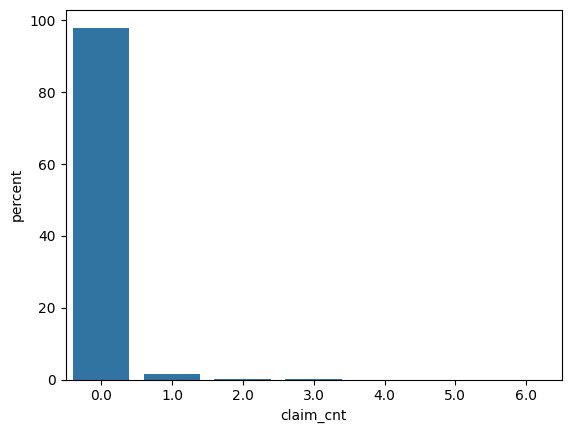

In [28]:
pdf = train_dfs['policy']
pdf['severity'] = np.where(
    pdf["claim_cnt"] > 0,
    pdf["claim_amount"] / pdf["claim_cnt"],
    0
)
pdf["log_severity"] = np.log1p(pdf["severity"])
sns.countplot(pdf, x='claim_cnt', stat='percent')

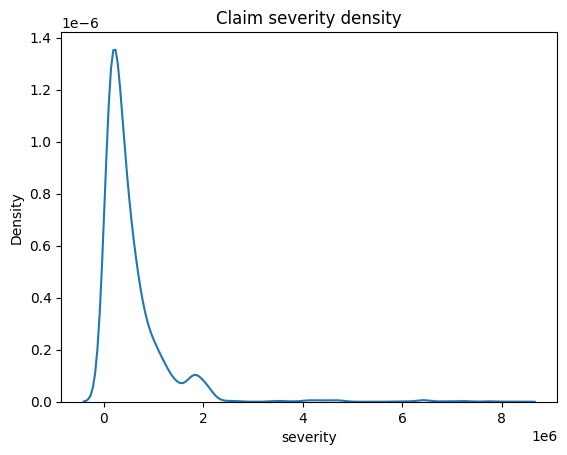

In [34]:
sns.kdeplot(pdf[pdf["severity"] > 0]["severity"])
plt.title("Claim severity density")
plt.show()

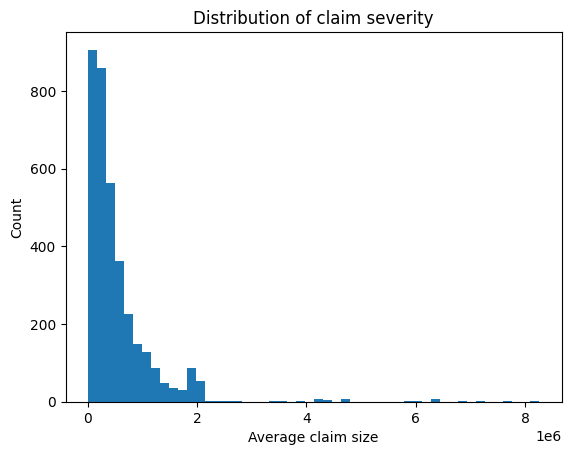

In [36]:
plt.hist(pdf[pdf["severity"] > 0]["severity"], bins=50)
plt.xlabel("Average claim size")
plt.ylabel("Count")
plt.title("Distribution of claim severity")
plt.show()

In [13]:
# Dumb strategy (increase everything)
train_after = train_dfs['policy'].copy()
k = train_loss_ratio / 70
train_after['premium'] = train_dfs['policy']['premium'].map(lambda p: k * p)
train_after['premium_wo_term'] = train_after['premium'] * (train_after['term'] / 100)

train_loss_ratio = loss_ratio(train_after)
print(f"Coefficient: {k:.2f}")
print(f"After Train Loss Ratio: {train_loss_ratio:.2f}%")

Coefficient: 1.63
After Train Loss Ratio: 70.00%


In [63]:
X = train_dfs['policy'].drop(columns=[
    'premium',
    "contract_number",
    "premium_wo_term",
    "term",
    "claim_amount",
    "claim_cnt",
    "is_claim",
    'severity', 'log_severity', 'p',
       'new_premium_rel', 'new_premium_wo_term'
])
X.fillna(0, inplace=True)
y = train_dfs['policy']["is_claim"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

print(X.columns)
print(X_train.shape, X_valid.shape)

Index(['experience_year', 'car_year', 'bonus_malus', 'engine_power',
       'n_drivers', 'n_cars'],
      dtype='str')
(144427, 6) (36107, 6)


In [64]:
# Regression strategy ( still bad )
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

proba = model.predict_proba(X_valid)[:,1]
auc = roc_auc_score(y_valid, proba)
print("AUC:", auc)
print(model.coef_)

AUC: 0.6304367235439841
[[-0.14819853  0.01882992 -0.36835162 -0.02754873 -0.01033468 -0.14385391]]


Best threshold = 0.59
Best f1-score = 0.07
TP = 207, FN = 515
FP = 5160, TN = 30225


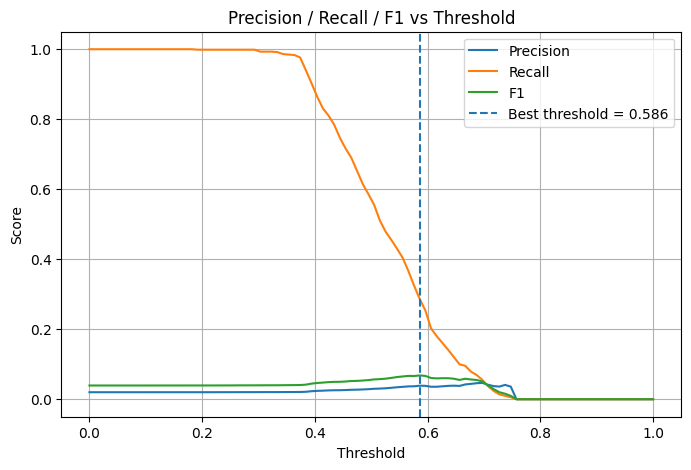

In [65]:
thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []
f1s = []

for threshold in thresholds:
    pred = (proba > threshold).astype(int)
    
    precisions.append(precision_score(y_valid, pred, zero_division=0))
    recalls.append(recall_score(y_valid, pred))
    f1s.append(f1_score(y_valid, pred))

best_idx = np.argmax(f1s)

best_threshold = thresholds[best_idx]
best_f1 = f1s[best_idx]

pred = (proba > best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel().tolist()

print(f"Best threshold = {best_threshold:.2f}")
print(f"Best f1-score = {best_f1:.2f}")
print(f"TP = {tp}, FN = {fn}\nFP = {fp}, TN = {tn}")

plt.figure(figsize=(8,5))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [71]:
policy_df = train_dfs['policy']
policy_df["p"] = model.predict_proba(scaler.transform(X))[:,1]
p_bar = policy_df["p"].mean()
base = policy_df["premium_wo_term"].values
claims = policy_df["claim_amount"].values  # actual claims sum used to compute LR

def compute_loss_ratio_for_alpha(alpha, lower_rel=0.0, upper_mult=3.0):
    rel = 1.0 + alpha * (policy_df["p"] - p_bar)
    # enforce lower/upper constraints on relativity
    rel = np.clip(rel, lower_rel, upper_mult) 
    new_p = base * rel
    lr = claims.sum() / new_p.sum()
    return lr, new_p, rel

# find alpha by simple bisection so LR ~= 0.7
target_lr = 0.7
a_low, a_high = -50.0, 200.0   # wide bounds; tune if needed
for _ in range(60):
    a_mid = 0.5*(a_low + a_high)
    lr_mid, _, _ = compute_loss_ratio_for_alpha(a_mid)
    if lr_mid > target_lr:
        # premiums too low on avg -> need larger alpha (increase premiums for high-risk)
        a_low = a_mid
    else:
        a_high = a_mid

alpha = 0.5*(a_low + a_high)
lr_final, new_p, rel = compute_loss_ratio_for_alpha(alpha)
print(f"alpha: {alpha}") 
print(f"Portfolio Loss Ratio: {lr_final}")

policy_df["new_premium_rel"] = rel
policy_df["new_premium_wo_term"] = new_p

increased = policy_df[policy_df["new_premium_rel"] > 1]
decreased = policy_df[policy_df["new_premium_rel"] <= 1]
false_increased = policy_df[(policy_df["is_claim"] == 0) & (policy_df["new_premium_rel"] > 1)]
false_decreased = policy_df[(policy_df["is_claim"] == 1) & (policy_df["new_premium_rel"] <= 1)]

n_false_inc = (false_increased.shape[0] / increased.shape[0]) * 100
n_false_dec = (false_decreased.shape[0] / decreased.shape[0]) * 100
print(f"Increased: {(increased.shape[0] / policy_df.shape[0]) * 100}%")
print(f"Falsely increased: {n_false_inc:.2f}%")
print(f"Falsely decreased: {n_false_dec:.2f}%")

alpha: 200.0
Portfolio Loss Ratio: 0.7699046213486014
Increased: 45.785835355113164%
Falsely increased: 97.26%
Falsely decreased: 1.34%


In [18]:
# Compute crash probability for mark ( it is difficult to compute correctly )

df = train_dfs['main']
policy_car = df[["contract_number", "car_number", "mark", "claim_cnt"]].drop_duplicates()
cars_per_policy = policy_car.groupby("contract_number")["car_number"].nunique().reset_index(name="n_cars")
policy_car = policy_car.merge(cars_per_policy, on="contract_number")
policy_car["claim_share"] = (
    policy_car["claim_cnt"] / policy_car["n_cars"]
)
car_claims = (
    policy_car
    .groupby("car_number").agg({
        "mark": 'first',
        "claim_share": "sum",
        "n_cars": lambda _: 1,
    })
    .reset_index()
)

s = car_claims.groupby('mark')[["claim_share", "n_cars"]].sum()
s['crash_prob'] = (s['claim_share'] / s['n_cars']) * 100
s[s['n_cars'] > 10].sort_values('crash_prob', ascending=False)

,claim_share,n_cars,crash_prob
mark,,,
ГАЗ-330252,4.0,27,14.814815
ГАЗ-3302,1.0,11,9.090909
LADA\t\t,1.0,12,8.333333
SCHWARZMUELLER,1.0,12,8.333333
HUMMER,3.0,39,7.692308
...,...,...,...
ОДАЗ,0.0,33,0.000000
СЗАП,0.0,27,0.000000
САЗ,0.0,31,0.000000


Text(0.5, 0, 'Год авто')

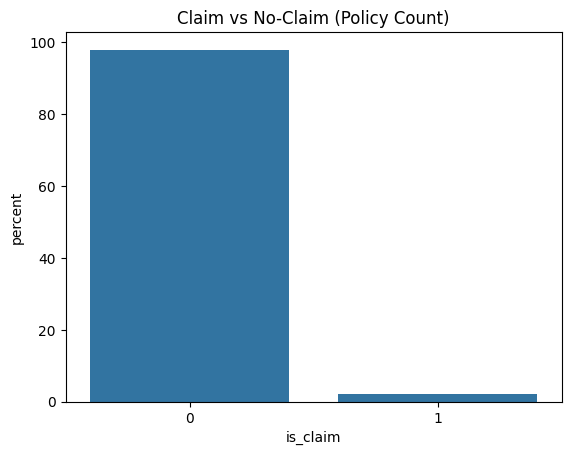

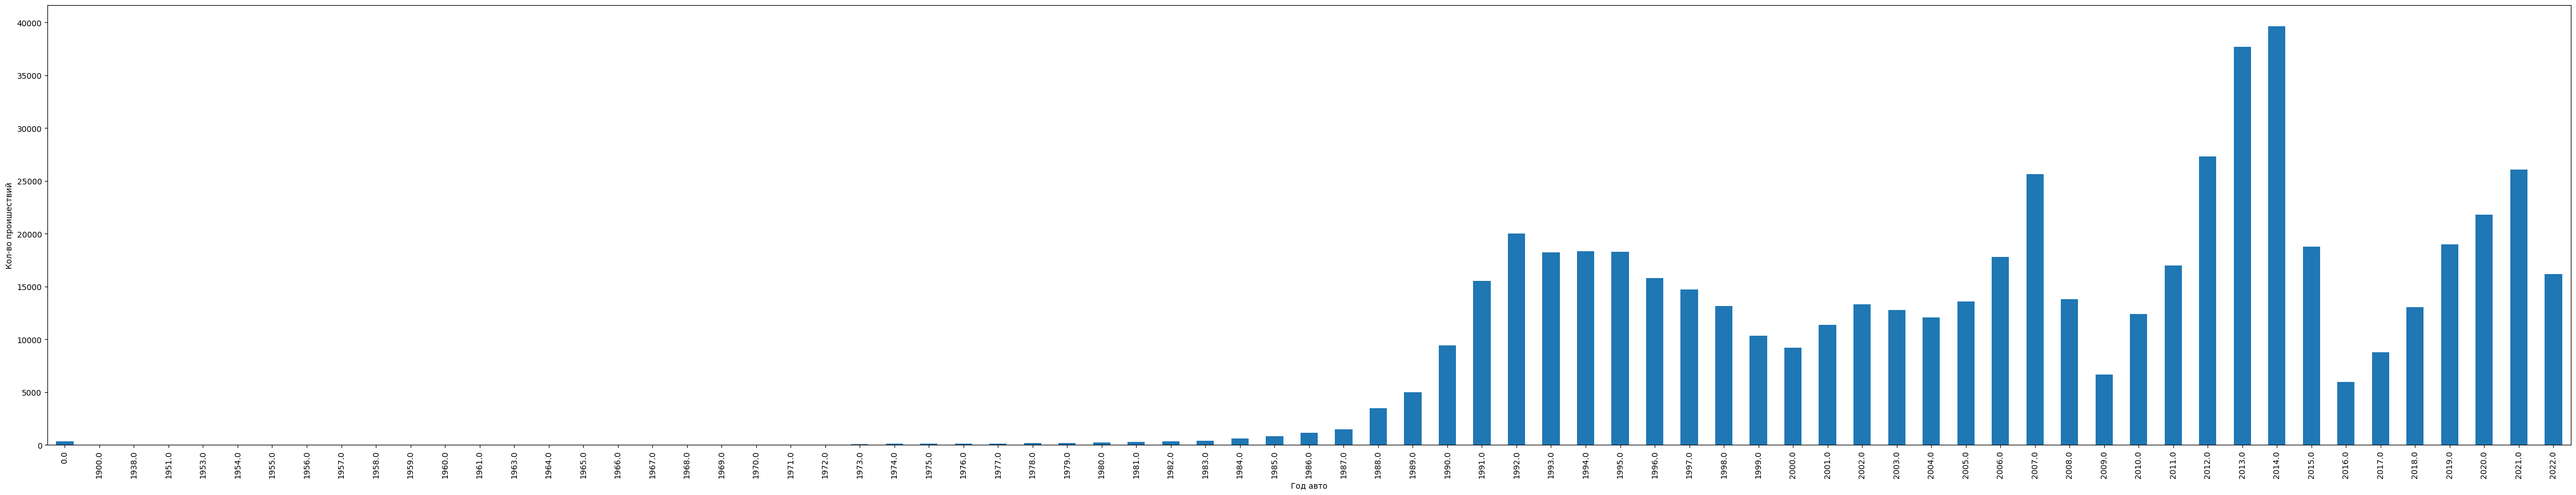

In [19]:
# Fancy plots go here

sns.countplot(x='is_claim', data=policy_df, stat='percent')
plt.title('Claim vs No-Claim (Policy Count)')

# This plot does not tell much, we can have just more cars of that year 
plt.figure(figsize=(57, 10))
train_dfs['main'].groupby('car_year')['is_claim'].count().plot.bar()
plt.ylabel("Кол-во проишествий")
plt.xlabel("Год авто")

In [20]:
for column in train_dfs['main'].columns:
    if column.endswith('_name'):
        print(column + ":")
        pprint(list(train_dfs['main'][column].unique()))
        print()

is_individual_person_name:
['Физ. лицо']

is_residence_name:
['Резидент', 'Не резидент']

region_name:
['01 Алматинская область',
 '18 Туркестанская область',
 '14 Мангистауская область',
 '17 Шымкент',
 '12 Кызылординская область',
 '05 Карагандинская область',
 '15 Алматы',
 '09 Жамбылская область',
 '07 Акмолинская область',
 '16 Астана',
 '13 Атырауская область',
 '10 Актюбинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '08 Павлодарская область',
 '11 Западно-Казахстанская область',
 '06 Северо-Казахстанская область',
 'Временная регистрация',
 'Временный въезд',
 '21 Улытауская область',
 '20 Жетысуйская область',
 '19 Абайская область']

age_experience_name:
['старше 25 лет/стаж вождения более 2 лет',
 'старше 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения более 2 лет']

vehicle_type_name:
['Легковые',
 'Прицепы(полуприцепы)',
 'Грузовые',
 'Мототранспорт',
 'Автобусы > 16 п.м.',
 'Авт